<a href="https://colab.research.google.com/github/Tanishtha-Reddy/CoVE-vs-SelfCheckGPT-analysis-on-LLM-hallucinations/blob/main/SelfCheckGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES, MODEL AND API KEYS


In [1]:
!pip install groq spacy bert-score pandas matplotlib seaborn tqdm
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 118.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
from groq import Groq
from google.colab import userdata

# Load the secret key
api_key = userdata.get('GROQ_API_KEY')

if not api_key:
    print("Error: API key not found.")
else:
    print("API key loaded successfully!")

# Create client
client = Groq(api_key=api_key)

# Quick test call
try:
    response = client.chat.completions.create(
        messages=[{"role": "user", "content": "groq is working.'"}],
        model="llama-3.1-8b-instant",
        temperature=0.0,
        max_tokens=50
    )
    print("\nTest response from Groq:")
    print(response.choices[0].message.content.strip())
except Exception as e:
    print("Error connecting to Groq:", str(e))

API key loaded successfully!

Test response from Groq:
It seems like you're referring to Groq, a company that specializes in building high-performance AI hardware and software. If Groq is working, it implies that their technology is operational and functioning as intended.

Groq is known for its high-performance AI


In [3]:
import json
from groq import Groq
from google.colab import userdata
import pandas as pd
from google.colab import files

client = Groq(api_key=userdata.get('GROQ_API_KEY'))

GENERATING 30 CODING QUESTIONS (10 OF HARD, MEDIUM AND EASY IFFICULTY) AND STORING IN ORIGINAL DATASET

In [4]:
import json
from groq import Groq
from google.colab import userdata

# Initialize Groq client
client = Groq(api_key=userdata.get('GROQ_API_KEY'))

# Quick test to confirm API works
try:
    test_resp = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": "Say OK"}],
        max_tokens=5
    )
    print("API test successful:", test_resp.choices[0].message.content.strip())
except Exception as e:
    print("API test failed:", str(e))

prompt = """
Generate exactly 30 coding interview-style questions with solutions. Balance them as follows:
- Exactly 10 easy, 10 medium, 10 hard difficulty.
- Distribute categories roughly evenly: DSA (algorithms/data structures), Frontend (JS/HTML/CSS/React/Vue basics), Backend (Node.js/Python/REST APIs), Database (SQL queries / simple schema design).
- Each question must be ONE concise sentence + 1-2 small input/output examples.
- Include both theory and coding questions.
- For each question, also provide a short, correct, concise code solution (Python or JavaScript) in the "generated_answer" field. Keep the code minimal (function or small script, no long explanations or comments).
- Output MUST be ONLY a clean JSON array of 30 objects — nothing else. No markdown, no explanations, no code fences, no trailing commas, no comments.
- Each object must have exactly these keys:
  "qid": "q01" to "q30" (string),
  "question": "one-line problem statement + examples",
  "category": one of "DSA", "Frontend", "Backend", "Database",
  "difficulty": "easy" / "medium" / "hard",
  "generated_answer": "short correct code solution as string (use \\n for line breaks)",
  "manual_verified_answer": ""   ← empty string
Ensure the JSON is valid and can be parsed directly with json.loads(). Keep "generated_answer" short (under 20 lines).
"""

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": prompt}],
    temperature=0.2,
    max_tokens=8192
)

raw_output = response.choices[0].message.content.strip()

print(" RAW OUTPUT PREVIEW (first 1000 chars)")
print(raw_output[:1000] + "..." if len(raw_output) > 1000 else raw_output)
print("\nTotal length of raw output:", len(raw_output))

API test successful: OK
 RAW OUTPUT PREVIEW (first 1000 chars)
[
  {"qid": "q01", "question": "Write a function to reverse a string, e.g. 'hello' -> 'olleh'", "category": "DSA", "difficulty": "easy", "generated_answer": "def reverse(s):\n  return s[::-1]", "manual_verified_answer": ""},
  {"qid": "q02", "question": "What is the difference between null and undefined in JavaScript, e.g. null == undefined -> true", "category": "Frontend", "difficulty": "easy", "generated_answer": "console.log(null == undefined)", "manual_verified_answer": ""},
  {"qid": "q03", "question": "Write a SQL query to select all users from a table, e.g. SELECT * FROM users", "category": "Database", "difficulty": "easy", "generated_answer": "SELECT * FROM users", "manual_verified_answer": ""},
  {"qid": "q04", "question": "Write a function to check if a number is prime, e.g. is_prime(5) -> true", "category": "DSA", "difficulty": "easy", "generated_answer": "def is_prime(n):\n  if n <= 1: return False\n  for i in r

In [5]:
from google.colab import files
import csv

cleaned_output = raw_output

if cleaned_output.startswith("```json"):
    cleaned_output = cleaned_output.split("```json", 1)[1].split("```", 1)[0].strip()
elif cleaned_output.startswith("```"):
    cleaned_output = cleaned_output.split("```", 2)[1].strip() if len(cleaned_output.split("```")) > 2 else cleaned_output

try:
    questions = json.loads(cleaned_output)
    print(f"\nSuccess! Parsed {len(questions)} questions.")

    # Save JSON
    json_path = '/content/dataset.json'
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(questions, f, indent=2, ensure_ascii=False)
    print(f"JSON saved: {json_path}")

    # Save as CSV
    csv_path = '/content/dataset.csv'
    if questions:
        headers = questions[0].keys()
        with open(csv_path, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=headers)
            writer.writeheader()
            writer.writerows(questions)
        print(f"CSV saved: {csv_path} (recommended for Excel)")

    # Auto-download both
    print("\nDownloading files")
    files.download(json_path)
    files.download(csv_path)

    # Preview
    print("\nFirst question:")
    print(json.dumps(questions[0], indent=2))

except json.JSONDecodeError as e:
    print("\nJSON parsing failed:", str(e))
    if hasattr(e, 'pos'):
        print("Problem near:", cleaned_output[max(0, e.pos-80):e.pos+80])



JSON parsing failed: Invalid control character at: line 24 column 624 (char 9516)
Problem near: end((node, neighbor))\n      for neighbor, neighbor_cost in graph[node].items():

  ...

  (truncated for brevity)

  {"qid": "q30", "question": "Write a functi


In [6]:
uploaded = files.upload()

Saving revised_original_dataset.csv to revised_original_dataset.csv


In [9]:
import pandas as pd
filename = 'revised_original_dataset.csv'

df = pd.read_csv(filename)
print("Dataset loaded. Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head(2))

Dataset loaded. Shape: (30, 6)

Columns: ['qid', 'question', 'category', 'difficulty', 'generated_answer', 'manual_verified_answer']


,qid,question,category,difficulty,generated_answer,manual_verified_answer
0,q01,"Write a function to reverse a string, e.g. 'he...",DSA,easy,def reverse(s):\n return s[::-1],def reverse(s): return s[::-1]
1,q02,"What is the difference between var, let, and c...",Frontend,easy,"var is function scoped, let and const are bloc...",var: Declares variables with function or globa...


In [10]:
required_cols = ['qid', 'question', 'generated_answer', 'manual_verified_answer']
missing = [col for col in required_cols if col not in df.columns]

if missing:
    print("Missing columns:", missing)
else:
    print("All required columns present ")
empty_gen = df['generated_answer'].isna().sum() + (df['generated_answer'] == '').sum()
print(f"Empty/missing generated_answer: {empty_gen}")

All required columns present 
Empty/missing generated_answer: 0


IMPLEMENTING SELFCHECKGPT

In [11]:
import spacy
from bert_score import score as bert_score
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from groq import Groq
from google.colab import userdata

nlp = spacy.load("en_core_web_sm")
client = Groq(api_key=userdata.get('GROQ_API_KEY'))

In [12]:
NUM_SAMPLES = 5
TEMPERATURE = 0.8
MODEL = "llama-3.1-8b-instant"

def split_into_sentences(text):
    """Split code/text into meaningful chunks (sentences or code blocks)"""
    if not text:
        return []
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents if sent.text.strip()]

def generate_sample(question):
    prompt = f"Solve this coding problem in Python or JavaScript:\n{question}\nProvide concise code only."
    try:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=TEMPERATURE,
            max_tokens=1024
        )
        return resp.choices[0].message.content.strip()
    except Exception as e:
        print("Generation error:", str(e))
        return ""

In [13]:
results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="SelfCheckGPT"):
    qid = row['qid']
    question = row['question']
    baseline = row['generated_answer']

    if not baseline or not baseline.strip():
        results.append({'qid': qid, 'selfcheck_halluc_score': np.nan, 'avg_baseline_sim': np.nan, 'is_flagged': False, 'num_chunks': 0, 'error': 'empty baseline'})
        continue

    try:
        baseline_chunks = split_into_sentences(baseline)

        samples = []
        for sample_num in range(NUM_SAMPLES):
            sample = generate_sample(question)
            if sample:
                samples.append(sample)
            else:
                print(f"Sample generation failed for {qid} sample {sample_num+1}")

        if not samples:
            raise ValueError("No valid samples generated")



        chunk_scores = []


        for chunk in baseline_chunks:
            sample_chunks_flat = [sub for samp in samples for sub in split_into_sentences(samp)]
            if sample_chunks_flat:
                P, R, F1 = bert_score([chunk] * len(sample_chunks_flat), sample_chunks_flat, lang="en", rescale_with_baseline=True)
                max_sim = F1.max().item()
                chunk_scores.append(max_sim)

        avg_sim = np.mean(chunk_scores) if chunk_scores else 0.0
        halluc_score = 1.0 - avg_sim
        is_flagged = halluc_score > 0.5

        results.append({
            'qid': qid,
            'selfcheck_halluc_score': halluc_score,
            'avg_baseline_sim': avg_sim,
            'is_flagged': is_flagged,
            'num_chunks': len(baseline_chunks)
        })

        print(f"{qid} done | score: {halluc_score:.3f} | flagged: {is_flagged}")

    except Exception as e:
        print(f"ERROR on {qid}: {str(e)}")
        results.append({
            'qid': qid,
            'selfcheck_halluc_score': np.nan,
            'avg_baseline_sim': np.nan,
            'is_flagged': False,
            'num_chunks': len(split_into_sentences(baseline)) if baseline else 0,
            'error': str(e)
        })

# After loop
df_results = pd.DataFrame(results)
df_results.to_csv('/content/result_detection_fixed.csv', index=False)
files.download('/content/result_detection_fixed.csv')

display(df_results)
print("Flagged count:", df_results['is_flagged'].sum())

SelfCheckGPT:   0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

q30 done | score: 0.633 | flagged: True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,qid,selfcheck_halluc_score,avg_baseline_sim,is_flagged,num_chunks
0,q01,0.778399,0.221601,True,1
1,q02,0.792320,0.207680,True,2
2,q03,0.876761,0.123239,True,2
3,q04,0.317658,0.682342,False,3
4,q05,0.577310,0.422690,True,1
5,q06,0.626117,0.373883,True,1
6,q07,0.618546,0.381454,True,1
7,q08,0.609408,0.390592,True,1
8,q09,0.634021,0.365979,True,1
9,q10,0.648380,0.351620,True,1


Flagged count: 21


In [16]:
P, R, F1 = bert_score([chunk] * len(sample_chunks_flat), sample_chunks_flat,
                              lang="en", rescale_with_baseline=True)
max_sim = F1.max().item()
chunk_scores.append(max_sim)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
df_results = pd.DataFrame(results)
df_results.to_csv('/content/result_detection.csv', index=False)
print("\nSelfCheckGPT results saved to result_detection.csv")
display(df_results.head())

files.download('/content/result_detection.csv')


SelfCheckGPT results saved to result_detection.csv


,qid,selfcheck_halluc_score,avg_baseline_sim,is_flagged,num_chunks
0,q01,0.778399,0.221601,True,1
1,q02,0.792320,0.207680,True,2
2,q03,0.876761,0.123239,True,2
3,q04,0.317658,0.682342,False,3
4,q05,0.577310,0.422690,True,1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
df_orig = pd.read_csv('/content/revised_original_dataset.csv')
print("Original dataset rows:", len(df_orig))
display(df_orig.head(3))

Original dataset rows: 30


,qid,question,category,difficulty,generated_answer,manual_verified_answer
0,q01,"Write a function to reverse a string, e.g. 'he...",DSA,easy,def reverse(s):\n return s[::-1],def reverse(s): return s[::-1]
1,q02,"What is the difference between var, let, and c...",Frontend,easy,"var is function scoped, let and const are bloc...",var: Declares variables with function or globa...
2,q03,Write a SQL query to select all rows from a ta...,Database,easy,SELECT * FROM users WHERE age > 18,SELECT * FROM users WHERE age > 18;


In [20]:
import pandas as pd

df_res = pd.read_csv('/content/result_detection.csv')
print("\nFlagged count:", df_res['is_flagged'].sum())
print("\nScore summary:\n", df_res['selfcheck_halluc_score'].describe())
print("\nFlagged rows preview:")
display(df_res[df_res['is_flagged'] == True].head(8))


Flagged count: 21

Score summary:
 count    30.000000
mean      0.524364
std       0.174374
min       0.189998
25%       0.403632
50%       0.555226
75%       0.631363
max       0.876761
Name: selfcheck_halluc_score, dtype: float64

Flagged rows preview:


,qid,selfcheck_halluc_score,avg_baseline_sim,is_flagged,num_chunks
0,q01,0.778399,0.221601,True,1
1,q02,0.792320,0.207680,True,2
2,q03,0.876761,0.123239,True,2
4,q05,0.577310,0.422690,True,1
5,q06,0.626117,0.373883,True,1
6,q07,0.618546,0.381454,True,1
7,q08,0.609408,0.390592,True,1
8,q09,0.634021,0.365979,True,1


VISUALIZATION

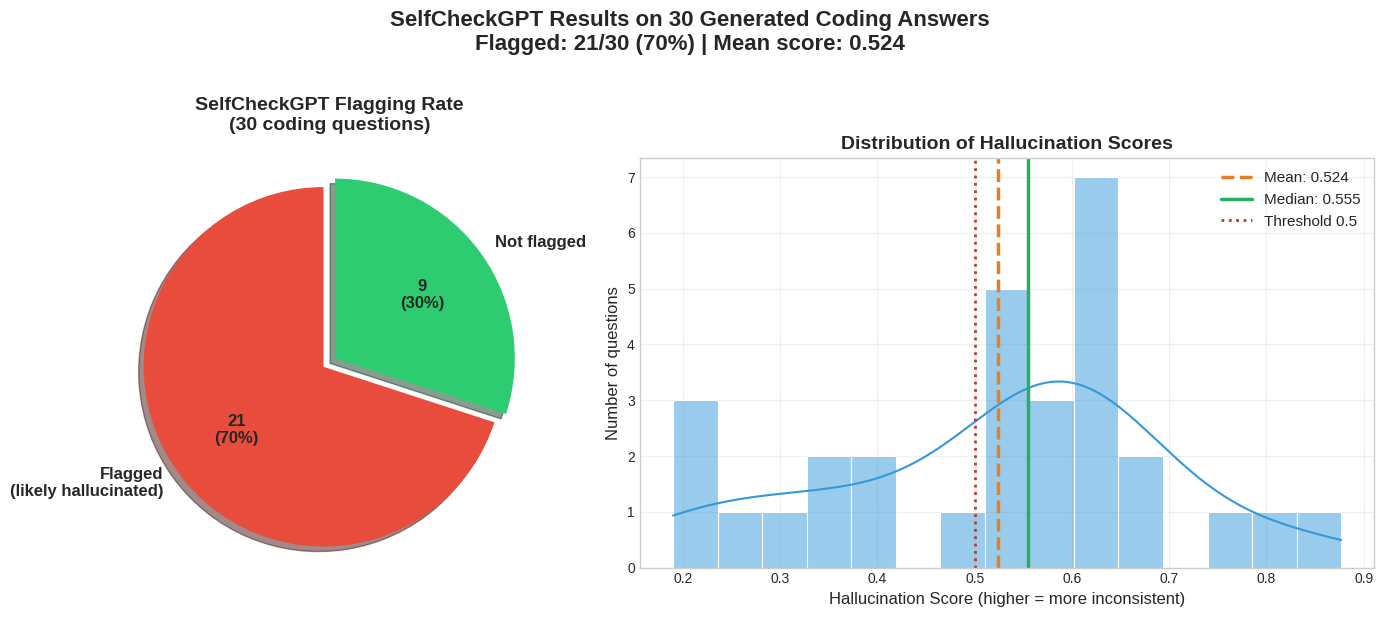

Graph saved as selfcheckgpt_results.png


<Figure size 640x480 with 0 Axes>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/content/result_detection.csv')

# Basic stats
total = len(df)
flagged = df['is_flagged'].sum()
not_flagged = total - flagged
mean_score = df['selfcheck_halluc_score'].mean()
median_score = df['selfcheck_halluc_score'].median()

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.8]})

labels = ['Flagged\n(likely hallucinated)', 'Not flagged']
sizes = [flagged, not_flagged]
colors = ['#e74c3c', '#2ecc71']
explode = (0.08, 0)

wedges, texts, autotexts = ax1.pie(sizes, explode=explode, labels=labels, colors=colors,
                                   autopct='%1.0f%%', shadow=True, startangle=90,
                                   textprops={'fontsize': 12, 'fontweight':'bold'})

ax1.set_title('SelfCheckGPT Flagging Rate\n(30 coding questions)', fontsize=14, fontweight='bold', pad=20)
ax1.axis('equal')


for i, a in enumerate(autotexts):
    a.set_text(f'{sizes[i]}\n({a.get_text()})')


sns.histplot(data=df, x='selfcheck_halluc_score', bins=15, kde=True, ax=ax2,
             color='#3498db', edgecolor='white', linewidth=0.8)


ax2.axvline(mean_score, color='#e67e22', linestyle='--', linewidth=2.5,
            label=f'Mean: {mean_score:.3f}')
ax2.axvline(median_score, color='#27ae60', linestyle='-', linewidth=2.5,
            label=f'Median: {median_score:.3f}')


ax2.axvline(0.5, color='#c0392b', linestyle=':', linewidth=2,
            label='Threshold 0.5')

ax2.set_title('Distribution of Hallucination Scores', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hallucination Score (higher = more inconsistent)', fontsize=12)
ax2.set_ylabel('Number of questions', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)


fig.suptitle('SelfCheckGPT Results on 30 Generated Coding Answers\n'
             f'Flagged: {flagged}/{total} ({flagged/total*100:.0f}%) | Mean score: {mean_score:.3f}',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


plt.savefig('selfcheckgpt_results.png', dpi=300, bbox_inches='tight')
print("Graph saved as selfcheckgpt_results.png")